<a href="https://colab.research.google.com/github/naelisa/FraudDetectionFIX/blob/main/CreditCardDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install streamlit pyngrok imbalanced-learn -q

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving creditcard_cleaned.csv to creditcard_cleaned (5).csv


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load dataset yang sudah di-cleaned
df = pd.read_csv("creditcard_cleaned.csv")

# Pisahkan fitur (X) dan target (y)
X = df.drop('Class', axis=1)
y = df['Class']

# Bagi data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Cetak hasil
print("=" * 50)
print("📊 HASIL PEMBAGIAN DATA")
print("=" * 50)
print(f"Data training : {X_train.shape}")
print(f"Data testing  : {X_test.shape}")
print(f"Jumlah fraud di training : {y_train.sum()}")
print(f"Jumlah fraud di testing  : {y_test.sum()}")
print(f"Total transaksi           : {len(df):,}")
print(f"Total fraud               : {df['Class'].sum():,}")
print("=" * 50)

📊 HASIL PEMBAGIAN DATA
Data training : (201632, 30)
Data testing  : (50409, 30)
Jumlah fraud di training : 309
Jumlah fraud di testing  : 77
Total transaksi           : 252,041
Total fraud               : 386


🔄 Memulai proses training model...

📌 Step 1/4: Menerapkan SMOTE...
   Sebelum SMOTE - Normal: 201323, Fraud: 309
   Setelah SMOTE - Normal: 201323, Fraud: 201323

📌 Step 2/4: Melatih Random Forest (100 pohon keputusan)...
   ✅ Random Forest selesai dalam 598.76 detik

🔥 HASIL RANDOM FOREST

📊 Classification Report - Random Forest:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     50332
           1       0.89      0.88      0.89        77

    accuracy                           1.00     50409
   macro avg       0.95      0.94      0.94     50409
weighted avg       1.00      1.00      1.00     50409

AUC Score - Random Forest: 0.9834


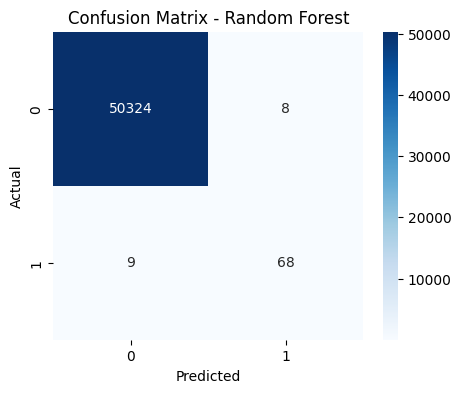


🎯 TOP 20 FEATURE IMPORTANCES - RANDOM FOREST


/tmp/ipykernel_75641/1964972742.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=importance_df, palette='viridis')


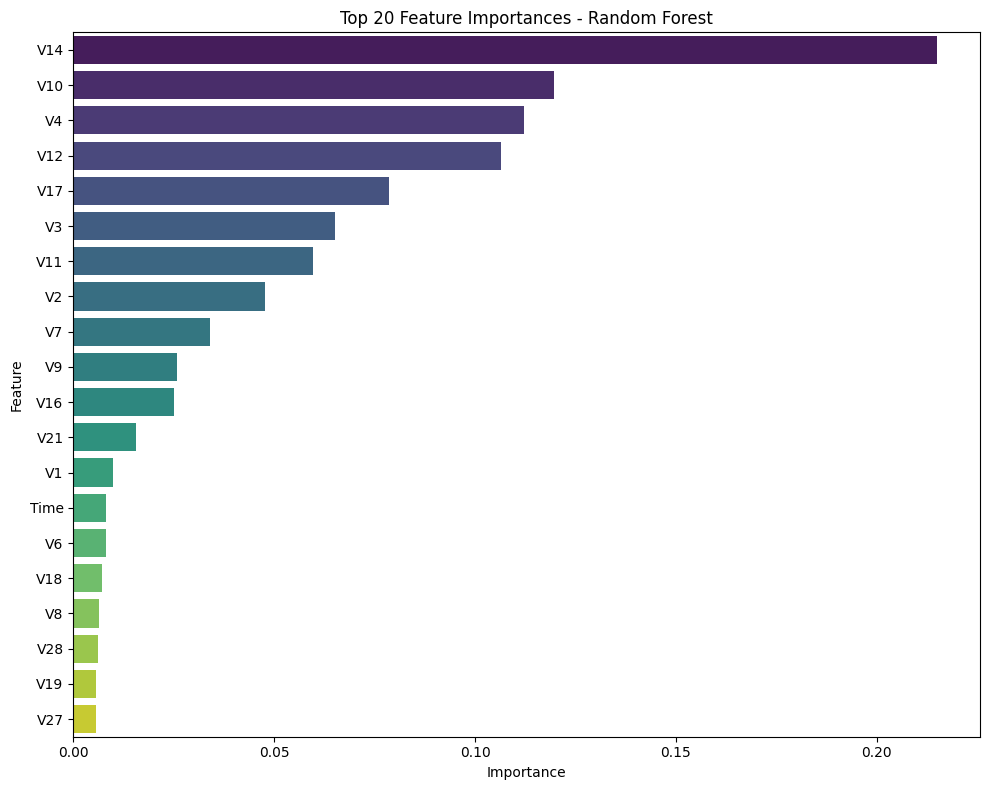


Top 5 Fitur Terpenting:
   1. V14: 0.2149
   2. V10: 0.1198
   3. V4: 0.1123
   4. V12: 0.1065
   5. V17: 0.0787

📌 Step 3/4: Melatih Logistic Regression...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


   ✅ Logistic Regression selesai dalam 111.35 detik

📈 HASIL LOGISTIC REGRESSION

📊 Classification Report - Logistic Regression:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     50332
           1       0.14      0.94      0.25        77

    accuracy                           0.99     50409
   macro avg       0.57      0.96      0.62     50409
weighted avg       1.00      0.99      0.99     50409

AUC Score - Logistic Regression: 0.9797


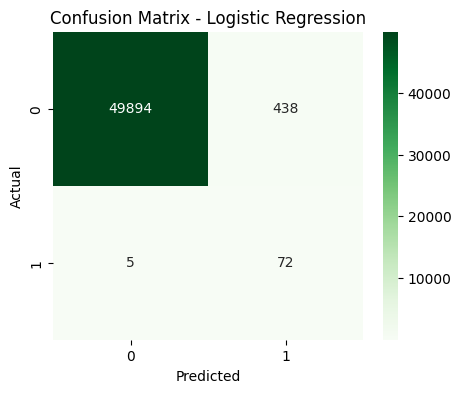


📌 Step 4/4: Membuat ROC Curve...


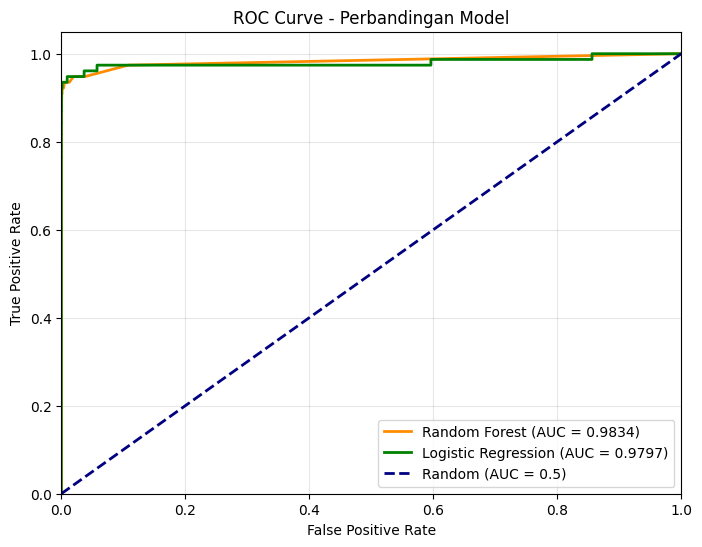


📊 PERBANDINGAN RANDOM FOREST vs LOGISTIC REGRESSION
              Model Accuracy Precision (Fraud) Recall (Fraud) F1-Score (Fraud)    AUC
      Random Forest   0.9997            0.8947         0.8831           0.8889 0.9834
Logistic Regression   0.9912            0.1412         0.9351           0.2453 0.9797

✅ SEMUA PROSES SELESAI! Total waktu: 712.30 detik


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import time

print("🔄 Memulai proses training model...")
start_time = time.time()

# ========== SMOTE ==========
print("\n📌 Step 1/4: Menerapkan SMOTE...")
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"   Sebelum SMOTE - Normal: {(y_train == 0).sum()}, Fraud: {(y_train == 1).sum()}")
print(f"   Setelah SMOTE - Normal: {(y_train_resampled == 0).sum()}, Fraud: {(y_train_resampled == 1).sum()}")

# ========== RANDOM FOREST ==========
print("\n📌 Step 2/4: Melatih Random Forest (100 pohon keputusan)...")
rf_start = time.time()
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_train_resampled, y_train_resampled)
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]
rf_time = time.time() - rf_start
print(f"   ✅ Random Forest selesai dalam {rf_time:.2f} detik")

print("\n" + "="*60)
print("🔥 HASIL RANDOM FOREST")
print("="*60)
print("\n📊 Classification Report - Random Forest:")
print(classification_report(y_test, y_pred_rf))

auc_rf = roc_auc_score(y_test, y_proba_rf)
print(f"AUC Score - Random Forest: {auc_rf:.4f}")

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# ========== FEATURE IMPORTANCE ==========
print("\n" + "="*60)
print("🎯 TOP 20 FEATURE IMPORTANCES - RANDOM FOREST")
print("="*60)

importances = rf.feature_importances_
importance_df = pd.DataFrame({'feature': X.columns, 'importance': importances})
importance_df = importance_df.sort_values('importance', ascending=False).head(20)

plt.figure(figsize=(10, 8))
sns.barplot(x='importance', y='feature', data=importance_df, palette='viridis')
plt.title('Top 20 Feature Importances - Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print("\nTop 5 Fitur Terpenting:")
for i in range(5):
    print(f"   {i+1}. {importance_df.iloc[i]['feature']}: {importance_df.iloc[i]['importance']:.4f}")

# ========== LOGISTIC REGRESSION ==========
print("\n📌 Step 3/4: Melatih Logistic Regression...")
lr_start = time.time()
lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr.fit(X_train_resampled, y_train_resampled)
y_pred_lr = lr.predict(X_test)
y_proba_lr = lr.predict_proba(X_test)[:, 1]
lr_time = time.time() - lr_start
print(f"   ✅ Logistic Regression selesai dalam {lr_time:.2f} detik")

print("\n" + "="*60)
print("📈 HASIL LOGISTIC REGRESSION")
print("="*60)
print("\n📊 Classification Report - Logistic Regression:")
print(classification_report(y_test, y_pred_lr))

auc_lr = roc_auc_score(y_test, y_proba_lr)
print(f"AUC Score - Logistic Regression: {auc_lr:.4f}")

# Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# ========== ROC CURVE ==========
print("\n📌 Step 4/4: Membuat ROC Curve...")
plt.figure(figsize=(8, 6))
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)

plt.plot(fpr_rf, tpr_rf, color='darkorange', lw=2, label=f'Random Forest (AUC = {auc_rf:.4f})')
plt.plot(fpr_lr, tpr_lr, color='green', lw=2, label=f'Logistic Regression (AUC = {auc_lr:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Perbandingan Model')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

# ========== PERBANDINGAN AKHIR ==========
print("\n" + "="*60)
print("📊 PERBANDINGAN RANDOM FOREST vs LOGISTIC REGRESSION")
print("="*60)

comparison = pd.DataFrame([
    {
        'Model': 'Random Forest',
        'Accuracy': f"{accuracy_score(y_test, y_pred_rf):.4f}",
        'Precision (Fraud)': f"{precision_score(y_test, y_pred_rf):.4f}",
        'Recall (Fraud)': f"{recall_score(y_test, y_pred_rf):.4f}",
        'F1-Score (Fraud)': f"{f1_score(y_test, y_pred_rf):.4f}",
        'AUC': f"{auc_rf:.4f}"
    },
    {
        'Model': 'Logistic Regression',
        'Accuracy': f"{accuracy_score(y_test, y_pred_lr):.4f}",
        'Precision (Fraud)': f"{precision_score(y_test, y_pred_lr):.4f}",
        'Recall (Fraud)': f"{recall_score(y_test, y_pred_lr):.4f}",
        'F1-Score (Fraud)': f"{f1_score(y_test, y_pred_lr):.4f}",
        'AUC': f"{auc_lr:.4f}"
    }
])

print(comparison.to_string(index=False))

# Total waktu
total_time = time.time() - start_time
print("\n" + "=" * 50)
print(f"✅ SEMUA PROSES SELESAI! Total waktu: {total_time:.2f} detik")
print("=" * 50)

In [41]:
# Matikan semua tunnel ngrok yang masih aktif
!pkill -f ngrok 2>/dev/null
!pkill -f streamlit 2>/dev/null

print("✅ Semua proses ngrok dan streamlit dimatikan")

^C
^C
✅ Semua proses ngrok dan streamlit dimatikan


In [42]:
from google.colab import userdata
from pyngrok import ngrok

# Ambil token dari Colab Secrets
ngrok.set_auth_token(userdata.get('NGROK_AUTH_TOKEN'))
print("✅ Ngrok auth token berhasil di-set!")

✅ Ngrok auth token berhasil di-set!


In [43]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score, precision_score, recall_score, f1_score
from imblearn.over_sampling import SMOTE
import plotly.express as px
import time

# ========== PAGE CONFIGURATION ==========
st.set_page_config(
    page_title="Fraud Detection System | Kelompok 13",
    page_icon="🔍",
    layout="wide",
    initial_sidebar_state="expanded"
)

# ========== CUSTOM CSS ==========
st.markdown("""
<style>
    @import url('https://fonts.googleapis.com/css2?family=Inter:wght@400;500;600;700;800&display=swap');

    * { font-family: 'Inter', sans-serif; }

    /* Background gelap */
    .stApp {
        background: linear-gradient(135deg, #1a1a2e 0%, #16213e 100%);
    }

    /* Main header */
    .main-header {
        background: linear-gradient(135deg, #0f0f23 0%, #1a1a2e 50%, #16213e 100%);
        padding: 1.5rem;
        border-radius: 16px;
        margin-bottom: 1.5rem;
        text-align: center;
        box-shadow: 0 4px 6px -1px rgba(0,0,0,0.3);
    }

    .main-header h1 {
        color: white;
        font-size: 1.8rem;
        font-weight: 700;
        margin: 0;
    }

    .main-header p {
        color: #a8dadc;
        font-size: 0.9rem;
        margin-top: 0.5rem;
    }

    /* Sidebar gelap */
    [data-testid="stSidebar"] {
        background: linear-gradient(180deg, #0f0f23 0%, #1a1a2e 100%);
    }

    [data-testid="stSidebar"] .stMarkdown {
        color: #ffffff !important;
    }

    [data-testid="stSidebar"] .stMarkdown p {
        color: #ffffff !important;
    }

    [data-testid="stSidebar"] .stSelectbox label {
        color: #ffffff !important;
    }

    [data-testid="stSidebar"] .stSlider label {
        color: #ffffff !important;
    }

    [data-testid="stSidebar"] .stCheckbox label {
        color: #ffffff !important;
    }

    [data-testid="stSidebar"] .stRadio label {
        color: #ffffff !important;
    }

    /* Selectbox di sidebar - biar keliatan */
    [data-testid="stSidebar"] .stSelectbox div[data-baseweb="select"] div {
        background-color: #ffffff !important;
        color: #1e293b !important;
    }

    [data-testid="stSidebar"] .stSelectbox svg {
        fill: #1e293b !important;
    }

    [data-baseweb="popover"] ul {
        background-color: #ffffff !important;
    }

    [data-baseweb="popover"] ul li div {
        color: #1e293b !important;
    }

    /* Metric Cards - gelap dengan border */
    .metric-card {
        background: rgba(255,255,255,0.08);
        backdrop-filter: blur(10px);
        border-radius: 12px;
        padding: 1rem;
        text-align: center;
        border: 1px solid rgba(255,255,255,0.1);
    }

    .metric-card h3 {
        font-size: 0.75rem;
        font-weight: 600;
        text-transform: uppercase;
        letter-spacing: 0.5px;
        color: #a8dadc;
        margin-bottom: 0.5rem;
    }

    .metric-card .value {
        font-size: 1.8rem;
        font-weight: 700;
        color: white;
        margin: 0;
    }

    /* Sample Card */
    .sample-card {
        background: rgba(255,255,255,0.08);
        backdrop-filter: blur(10px);
        border-radius: 12px;
        padding: 1rem;
        margin-bottom: 0.75rem;
        transition: all 0.2s ease;
        border: 1px solid rgba(255,255,255,0.1);
    }

    .sample-card:hover {
        transform: translateY(-2px);
        background: rgba(255,255,255,0.12);
        border-color: #3b82f6;
    }

    .sample-card strong {
        color: white;
    }

    .fraud-badge {
        background: #dc2626;
        color: white;
        padding: 0.2rem 0.6rem;
        border-radius: 20px;
        font-size: 0.7rem;
        font-weight: 600;
        display: inline-block;
    }

    .normal-badge {
        background: #10b981;
        color: white;
        padding: 0.2rem 0.6rem;
        border-radius: 20px;
        font-size: 0.7rem;
        font-weight: 600;
        display: inline-block;
    }

    /* Custom Subheader */
    .custom-subheader {
        font-size: 1.2rem;
        font-weight: 600;
        color: white;
        margin-top: 1rem;
        margin-bottom: 1rem;
        padding-left: 0.75rem;
        border-left: 3px solid #ef4444;
    }

    /* Divider */
    .custom-divider {
        height: 1px;
        background: linear-gradient(90deg, #ef4444, #f59e0b, #10b981, #3b82f6);
        margin: 1rem 0;
    }

    /* Footer */
    .footer {
        text-align: center;
        padding: 1.5rem;
        margin-top: 2rem;
        color: #9ca3af;
        font-size: 0.75rem;
        border-top: 1px solid #334155;
    }

    /* Button */
    .stButton > button {
        background: linear-gradient(135deg, #ef4444 0%, #dc2626 100%);
        color: white;
        border: none;
        border-radius: 8px;
        padding: 0.5rem 1rem;
        font-weight: 500;
        transition: all 0.2s ease;
        width: 100%;
    }

    .stButton > button:hover {
        transform: scale(0.98);
        box-shadow: 0 4px 15px rgba(239,68,68,0.3);
    }

    /* Result Box */
    .fraud-result {
        background: linear-gradient(135deg, #dc2626 0%, #b91c1c 100%);
        padding: 1.5rem;
        border-radius: 16px;
        text-align: center;
        color: white;
    }

    .normal-result {
        background: linear-gradient(135deg, #10b981 0%, #059669 100%);
        padding: 1.5rem;
        border-radius: 16px;
        text-align: center;
        color: white;
    }

    .result-text {
        font-size: 1.5rem;
        font-weight: 700;
        margin: 0;
    }

    .probability-text {
        font-size: 1rem;
        margin-top: 0.5rem;
    }

    .confidence-bar {
        height: 30px;
        background: rgba(255,255,255,0.3);
        border-radius: 15px;
        overflow: hidden;
        margin: 1rem 0;
    }

    .confidence-fill {
        height: 100%;
        background: white;
        border-radius: 15px;
        display: flex;
        align-items: center;
        justify-content: center;
        font-weight: 600;
        font-size: 0.85rem;
    }

    /* Dataframe */
    .stDataFrame {
        background: rgba(255,255,255,0.05);
        border-radius: 12px;
        overflow: hidden;
    }

    .stDataFrame table {
        color: white !important;
    }

    /* Metric row */
    [data-testid="stMetric"] {
        background: rgba(255,255,255,0.08);
        border-radius: 12px;
        padding: 0.5rem;
    }

    [data-testid="stMetric"] label {
        color: #a8dadc !important;
    }

    [data-testid="stMetric"] .stMetricValue {
        color: white !important;
    }

    /* Info, warning, success */
    .stAlert {
        background: rgba(255,255,255,0.08) !important;
        color: white !important;
    }

    .stAlert p {
        color: white !important;
    }

    /* Plot background */
    .js-plotly-plot .plotly .main-svg {
        background: transparent !important;
    }

    /* Text umum */
    p, div, span, label {
        color: white !important;
    }

    /* Expander */
    .streamlit-expanderHeader {
        color: white !important;
        background: rgba(255,255,255,0.05) !important;
    }
</style>
""", unsafe_allow_html=True)

# ========== HEADER ==========
st.markdown("""
<div class="main-header">
    <h1>🔍 Credit Card Fraud Detection System</h1>
    <p>Deteksi Transaksi Fraud | Random Forest vs Logistic Regression | Kelompok 13</p>
</div>
""", unsafe_allow_html=True)

# ========== LOAD DATA ==========
@st.cache_data
def load_default_data():
    try:
        df = pd.read_csv("creditcard_cleaned.csv")
        return df
    except FileNotFoundError:
        st.error("❌ File 'creditcard_cleaned.csv' tidak ditemukan.")
        return None

# ========== TRAIN MODEL ==========
def train_model(df, test_size, selected_model):
    X = df.drop('Class', axis=1)
    y = df['Class']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42, stratify=y)

    smote = SMOTE(random_state=42)
    X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

    if selected_model == "Random Forest":
        model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1)
        model.fit(X_resampled, y_resampled)
        model_name = "Random Forest"
    else:
        model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
        model.fit(X_resampled, y_resampled)
        model_name = "Logistic Regression"

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_proba)

    rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1)
    lr_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
    rf_model.fit(X_resampled, y_resampled)
    lr_model.fit(X_resampled, y_resampled)

    y_pred_rf = rf_model.predict(X_test)
    y_pred_lr = lr_model.predict(X_test)

    return {
        'model': model,
        'model_name': model_name,
        'X_test': X_test,
        'y_test': y_test,
        'y_pred': y_pred,
        'y_proba': y_proba,
        'auc': auc,
        'y_pred_rf': y_pred_rf,
        'y_pred_lr': y_pred_lr,
        'X_columns': X.columns.tolist(),
        'rf_model': rf_model,
        'lr_model': lr_model
    }

# ========== SESSION STATE ==========
if 'trained_model' not in st.session_state:
    st.session_state.trained_model = None
if 'model_info' not in st.session_state:
    st.session_state.model_info = None
if 'df' not in st.session_state:
    st.session_state.df = None
if 'detection_result' not in st.session_state:
    st.session_state.detection_result = None
if 'selected_sample' not in st.session_state:
    st.session_state.selected_sample = None

# ========== LOAD DATA ==========
if st.session_state.df is None:
    with st.spinner("Memuat dataset..."):
        df = load_default_data()
        if df is not None:
            st.session_state.df = df

# ========== SIDEBAR ==========
with st.sidebar:
    st.markdown("### ⚙️ Pengaturan")
    st.markdown("---")

    page = st.radio("📌 Navigasi", ["Training & Evaluasi Model", "Deteksi Fraud"])
    st.markdown("---")

    if page == "Training & Evaluasi Model" and st.session_state.df is not None:
        show_raw_data = st.checkbox("Tampilkan Data Mentah")
        test_size = st.slider("Test Size", 0.1, 0.4, 0.2)  # <--- DIPERBAIKI: HAPUS value=
        selected_model = st.selectbox("Pilih Model", ["Random Forest", "Logistic Regression"])
        st.markdown("---")
        train_btn = st.button("🚀 Train Model", use_container_width=True)

# ========== PAGE: TRAINING ==========
if page == "Training & Evaluasi Model":
    if st.session_state.df is None:
        st.error("Dataset tidak tersedia. Pastikan file 'creditcard_cleaned.csv' ada.")
    else:
        df = st.session_state.df

        # Data Overview
        st.markdown('<div class="custom-subheader">📊 Data Overview</div>', unsafe_allow_html=True)

        col1, col2, col3, col4 = st.columns(4)

        with col1:
            st.markdown(f"""
            <div class="metric-card">
                <h3>TOTAL TRANSAKSI</h3>
                <div class="value">{len(df):,}</div>
            </div>
            """, unsafe_allow_html=True)

        with col2:
            st.markdown(f"""
            <div class="metric-card">
                <h3>TOTAL FRAUD</h3>
                <div class="value">{df['Class'].sum():,}</div>
            </div>
            """, unsafe_allow_html=True)

        with col3:
            st.markdown(f"""
            <div class="metric-card">
                <h3>TOTAL NORMAL</h3>
                <div class="value">{(df['Class'] == 0).sum():,}</div>
            </div>
            """, unsafe_allow_html=True)

        with col4:
            fraud_pct = (df['Class'].sum()/len(df))*100
            st.markdown(f"""
            <div class="metric-card">
                <h3>FRAUD RATE</h3>
                <div class="value">{fraud_pct:.4f}%</div>
            </div>
            """, unsafe_allow_html=True)

        # Distribusi Visual
        st.markdown('<div class="custom-subheader">📊 Distribusi Fraud vs Normal</div>', unsafe_allow_html=True)

        col1, col2 = st.columns(2)

        with col1:
            fig1, ax1 = plt.subplots(figsize=(5, 3.5))
            colors = ['#10b981', '#dc2626']
            sns.countplot(x='Class', data=df, ax=ax1, palette=colors)
            ax1.set_xticklabels(['Normal', 'Fraud'])
            ax1.set_ylabel('Jumlah', color='white')
            ax1.set_title('Jumlah Transaksi', color='white')
            ax1.tick_params(colors='white')
            ax1.set_facecolor('#1a1a2e')
            fig1.patch.set_facecolor('#1a1a2e')
            st.pyplot(fig1)
            plt.close(fig1)

        with col2:
            fraud_count = df['Class'].sum()
            normal_count = len(df) - fraud_count
            fig2, ax2 = plt.subplots(figsize=(5, 3.5))
            ax2.pie([normal_count, fraud_count], labels=['Normal', 'Fraud'],
                    autopct='%1.2f%%', colors=['#10b981', '#dc2626'], startangle=90)
            ax2.set_title('Persentase', color='white')
            fig2.patch.set_facecolor('#1a1a2e')
            st.pyplot(fig2)
            plt.close(fig2)

        if show_raw_data:
            st.markdown('<div class="custom-subheader">📄 Data Mentah</div>', unsafe_allow_html=True)
            st.dataframe(df.head(100), use_container_width=True)

        # Training Button
        if train_btn:
            with st.spinner("🔄 Melatih model dengan SMOTE..."):
                result = train_model(df, test_size, selected_model)
                st.session_state.trained_model = result['model']
                st.session_state.model_info = result

            st.markdown(f'<div class="custom-subheader">📈 Hasil Evaluasi - {result["model_name"]}</div>', unsafe_allow_html=True)

            # Metrics
            col1, col2, col3, col4 = st.columns(4)
            with col1: st.metric("Accuracy", f"{accuracy_score(result['y_test'], result['y_pred']):.4f}")
            with col2: st.metric("Precision", f"{precision_score(result['y_test'], result['y_pred']):.4f}")
            with col3: st.metric("Recall", f"{recall_score(result['y_test'], result['y_pred']):.4f}")
            with col4: st.metric("F1-Score", f"{f1_score(result['y_test'], result['y_pred']):.4f}")

            # Confusion Matrix & ROC
            col1, col2 = st.columns(2)
            with col1:
                st.markdown("#### Confusion Matrix")
                cm = confusion_matrix(result['y_test'], result['y_pred'])
                fig_cm, ax_cm = plt.subplots(figsize=(5, 4))
                sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn', ax=ax_cm,
                           xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
                ax_cm.tick_params(colors='white')
                ax_cm.set_title('Confusion Matrix', color='white')
                fig_cm.patch.set_facecolor('#1a1a2e')
                ax_cm.set_facecolor('#1a1a2e')
                st.pyplot(fig_cm)
                plt.close(fig_cm)

            with col2:
                st.markdown("#### ROC Curve")
                fpr, tpr, _ = roc_curve(result['y_test'], result['y_proba'])
                fig_roc, ax_roc = plt.subplots(figsize=(5, 4))
                ax_roc.plot(fpr, tpr, color='#dc2626', lw=2, label=f'AUC = {result["auc"]:.4f}')
                ax_roc.plot([0, 1], [0, 1], color='#3b82f6', lw=2, linestyle='--')
                ax_roc.fill_between(fpr, tpr, alpha=0.2, color='#dc2626')
                ax_roc.set_xlabel('False Positive Rate', color='white')
                ax_roc.set_ylabel('True Positive Rate', color='white')
                ax_roc.legend()
                ax_roc.tick_params(colors='white')
                fig_roc.patch.set_facecolor('#1a1a2e')
                ax_roc.set_facecolor('#1a1a2e')
                st.pyplot(fig_roc)
                plt.close(fig_roc)
                st.metric("AUC Score", f"{result['auc']:.4f}")

            # Perbandingan Model
            st.markdown("#### Perbandingan Random Forest vs Logistic Regression")
            comparison = pd.DataFrame([
                {'Model': 'Random Forest',
                 'Accuracy': round(accuracy_score(result['y_test'], result['y_pred_rf']), 4),
                 'Precision': round(precision_score(result['y_test'], result['y_pred_rf']), 4),
                 'Recall': round(recall_score(result['y_test'], result['y_pred_rf']), 4),
                 'F1-Score': round(f1_score(result['y_test'], result['y_pred_rf']), 4)},
                {'Model': 'Logistic Regression',
                 'Accuracy': round(accuracy_score(result['y_test'], result['y_pred_lr']), 4),
                 'Precision': round(precision_score(result['y_test'], result['y_pred_lr']), 4),
                 'Recall': round(recall_score(result['y_test'], result['y_pred_lr']), 4),
                 'F1-Score': round(f1_score(result['y_test'], result['y_pred_lr']), 4)}
            ])
            st.dataframe(comparison, use_container_width=True)

            st.success(f"✅ {result['model_name']} berhasil dilatih!")
            st.balloons()

# ========== PAGE: DETEKSI FRAUD ==========
if page == "Deteksi Fraud":
    st.markdown('<div class="custom-subheader">🎯 Coba Deteksi Fraud</div>', unsafe_allow_html=True)

    if st.session_state.trained_model is None:
        st.warning("⚠️ Belum ada model yang dilatih.")
        st.info("Silakan pergi ke halaman **Training & Evaluasi Model** terlebih dahulu untuk melatih model.")
    else:
        st.success("✅ Model sudah siap. Pilih sample transaksi di bawah untuk diprediksi.")
        st.markdown("---")

        df = st.session_state.df

        # Ambil sample (5 fraud + 5 normal)
        normal_samples = df[df['Class'] == 0].sample(min(5, len(df[df['Class'] == 0])), random_state=42)
        fraud_samples = df[df['Class'] == 1].sample(min(5, len(df[df['Class'] == 1])), random_state=42)
        all_samples = pd.concat([normal_samples, fraud_samples]).sample(frac=1, random_state=42).reset_index(drop=True)

        # Tampilkan sample dalam 2 kolom
        cols = st.columns(2)
        for idx, (i, row) in enumerate(all_samples.iterrows()):
            col_idx = idx % 2
            with cols[col_idx]:
                is_fraud = row['Class'] == 1
                badge = '<span class="fraud-badge">⚠️ FRAUD</span>' if is_fraud else '<span class="normal-badge">✅ NORMAL</span>'

                st.markdown(f"""
                <div class="sample-card">
                    <div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 0.5rem;">
                        <strong>Transaksi #{i+1}</strong>
                        {badge}
                    </div>
                    <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 0.4rem; font-size: 0.8rem;">
                        <div style="color: #a8dadc;">💰 Amount:</div>
                        <div>Rp {row['Amount']:,.0f}</div>
                        <div style="color: #a8dadc;">📊 V1:</div>
                        <div>{row['V1']:.4f}</div>
                        <div style="color: #a8dadc;">📊 V2:</div>
                        <div>{row['V2']:.4f}</div>
                    </div>
                </div>
                """, unsafe_allow_html=True)

                if st.button(f"🔍 Prediksi #{i+1}", key=f"pred_{idx}"):
                    model = st.session_state.trained_model
                    features = row.drop('Class').values.reshape(1, -1)

                    prediction = model.predict(features)[0]
                    proba = model.predict_proba(features)[0]

                    st.session_state.detection_result = {
                        'prediction': prediction,
                        'fraud_prob': proba[1] * 100,
                        'normal_prob': proba[0] * 100,
                        'actual': row['Class'],
                        'amount': row['Amount']
                    }
                    st.session_state.selected_sample = row
                    st.rerun()

        # Hasil Prediksi
        if st.session_state.detection_result is not None:
            st.markdown('<div class="custom-divider"></div>', unsafe_allow_html=True)
            st.markdown('<div class="custom-subheader">📋 Hasil Prediksi</div>', unsafe_allow_html=True)

            res = st.session_state.detection_result

            if res['prediction'] == 1:
                st.markdown(f"""
                <div class="fraud-result">
                    <div class="result-text">⚠️ FRAUD TERDETEKSI!</div>
                    <div class="probability-text">Probabilitas Fraud: {res['fraud_prob']:.1f}%</div>
                    <div class="confidence-bar">
                        <div class="confidence-fill" style="width: {res['fraud_prob']}%; color: #dc2626;">
                            {res['fraud_prob']:.1f}%
                        </div>
                    </div>
                </div>
                """, unsafe_allow_html=True)
            else:
                st.markdown(f"""
                <div class="normal-result">
                    <div class="result-text">✅ TRANSAKSI NORMAL</div>
                    <div class="probability-text">Probabilitas Normal: {res['normal_prob']:.1f}%</div>
                    <div class="confidence-bar">
                        <div class="confidence-fill" style="width: {res['normal_prob']}%; color: #059669;">
                            {res['normal_prob']:.1f}%
                        </div>
                    </div>
                </div>
                """, unsafe_allow_html=True)

            # Akurasi
            if res['prediction'] == res['actual']:
                st.success(f"✅ Prediksi SESUAI! (Aktual: {'FRAUD' if res['actual']==1 else 'NORMAL'})")
            else:
                st.error(f"❌ Prediksi TIDAK SESUAI! (Aktual: {'FRAUD' if res['actual']==1 else 'NORMAL'})")

            # Tombol reset
            if st.button("🔄 Coba Transaksi Lain", use_container_width=True):
                st.session_state.detection_result = None
                st.session_state.selected_sample = None
                st.rerun()

# ========== FOOTER ==========
st.markdown("""
<div class="footer">
    <p>Credit Card Fraud Detection System | Kelompok 13</p>
    <p>Random Forest & Logistic Regression | SMOTE untuk handling imbalanced data</p>
</div>
""", unsafe_allow_html=True)

Overwriting app.py


In [44]:
import threading
import time
import subprocess
from pyngrok import ngrok

print("🔄 Memulai proses deployment dashboard...")

# Matikan proses lama
!pkill -f streamlit 2>/dev/null
!pkill -f ngrok 2>/dev/null
print("   ✅ Proses lama dimatikan")
time.sleep(2)

def run_streamlit():
    subprocess.run(["streamlit", "run", "app.py", "--server.port=8501", "--server.headless=true"])

print("   🚀 Menjalankan Streamlit...")
t = threading.Thread(target=run_streamlit, daemon=True)
t.start()

print("   ⏳ Menunggu Streamlit siap (8 detik)...")
time.sleep(8)

print("   🔗 Membuat tunnel ngrok...")
public_url = ngrok.connect(8501)

print("\n" + "=" * 60)
print(f"✅ Dashboard dapat diakses di: {public_url}")
print("=" * 60)
print("\n📝 Catatan:")
print("   - Dashboard akan tetap berjalan selama session Colab aktif")
print("   - Klik Ctrl + Klik pada link di atas untuk membuka")
print("   - Proses training akan muncul progress bar sesuai pilihan model!")
print("   - Fitur deteksi membutuhkan input V1-V28 lengkap (sudah ditambahkan)")
print("   - Jangan lupa matikan tunnel setelah selesai dengan: ngrok.kill()")

🔄 Memulai proses deployment dashboard...
^C
^C
   ✅ Proses lama dimatikan
   🚀 Menjalankan Streamlit...
   ⏳ Menunggu Streamlit siap (8 detik)...
   🔗 Membuat tunnel ngrok...

✅ Dashboard dapat diakses di: NgrokTunnel: "https://cathedral-uncurious-sandy.ngrok-free.dev" -> "http://localhost:8501"

📝 Catatan:
   - Dashboard akan tetap berjalan selama session Colab aktif
   - Klik Ctrl + Klik pada link di atas untuk membuka
   - Proses training akan muncul progress bar sesuai pilihan model!
   - Fitur deteksi membutuhkan input V1-V28 lengkap (sudah ditambahkan)
   - Jangan lupa matikan tunnel setelah selesai dengan: ngrok.kill()
